# QuBridge - 論理テレポーテーション walkthrough

[[2,1,1]] 反復符号で encode された 6 量子ビット論理テレポーテーション回路の構築から、IBM Torino 上での VF2 layout 選択、ノイズモデルシミュレーション、フィデリティ計算までを 1 本で追う。

論文 Table V の (noise=1.0, |+⟩, logical) 行 (Phys F = 0.9849 / Log F = 0.9769 / Accept = 0.9263) を再現する。

回路は `qubridge_logical.create_deferred_logical_teleportation_circuit` を使用 (`services.mode3_computation` から vendoring)。Ltelepo notebook の元プロトコル (Method 2: CX_L + H_L decode-encode) を踏襲しつつ、deferred measurement 形に変換した版で、密度行列シミュレーションに直接渡せる。

In [42]:
import sys, os, math
# Walkthrough imports use the vendored `qubridge_logical/` package next to
# this notebook's parent directory. Add the artifact root to sys.path.
_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
from qiskit import transpile
from qiskit.transpiler import CouplingMap
from qiskit_aer import AerSimulator

from qubridge_logical import (
    create_deferred_logical_teleportation_circuit,
    compute_dm_fidelity_logical,
    compute_dm_fidelity_physical,
    select_qubits_qubridge_logical,
    create_reduced_noise_model,
    DEFAULT_GATE_PULSE_MAP,
    load_static_backend_data,
)

## 1. 入力状態と論理回路の構築

stress-test 用の |+⟩ 状態 (θ=π/2, φ=0) を準備する。論理ビット 6 個の役割：

| index | 役割 |
|---|---|
| 0, 1 | Alice (符号化された |ψ_L⟩) |
| 2, 3 | Mediator (符号化 Bell pair の片側) |
| 4, 5 | Bob (Mediator から entangle される) |

In [ ]:
theta = math.pi / 2  # |+⟩
phi = 0.0
qc = create_deferred_logical_teleportation_circuit(theta, phi)
print(f'Qubits: {qc.num_qubits}')
_pre_ops = qc.count_ops()
print(f'Pre-transpile 2Q gates: {_pre_ops.get("cx", 0) + _pre_ops.get("cz", 0)}')
qc.draw('mpl', fold=-1)

## 2. IBM Torino 上で VF2 layout を選ぶ

論理回路の必要接続を heavy-hex に embed できる物理 6 量子ビットを VF2 で列挙し、ノイズスコア最良を選ぶ。テンプレートは tree 形の 5 edges (Alice 内 (0,1), Alice→Med (1,2), Med 内 (2,3), Med→Bob (3,4), Med→Bob (3,5))。

In [44]:
backend_name = 'ibm_torino'
# E3DConfig と同じ条件 (threshold=1.0, seed=42) で再現性を担保
selected = select_qubits_qubridge_logical(backend_name, threshold=1.0, seed=42)
labels = ['Alice_0', 'Alice_1', 'Med_0', 'Med_1', 'Bob_0', 'Bob_1']
for lbl, q in zip(labels, selected):
    print(f'  {lbl:8s} (logical) -> physical {q}')

  Alice_0  (logical) -> physical 60
  Alice_1  (logical) -> physical 61
  Med_0    (logical) -> physical 62
  Med_1    (logical) -> physical 63
  Bob_0    (logical) -> physical 73
  Bob_1    (logical) -> physical 64


## 3. transpile して routing SWAP を確認

VF2 が確保するのは tree 5 edges のみ。回路は実際にはより多くの 2Q 接続を要求するため、transpiler が SWAP を挿入する。

In [45]:
data = load_static_backend_data(backend_name)
cm = CouplingMap(couplinglist=data['coupling_map'])
basis = ['sx', 'x', 'rz', 'cz', 'id', 'measure']
qct = transpile(qc, basis_gates=basis, coupling_map=cm,
                initial_layout=selected, optimization_level=3,
                seed_transpiler=42)
ops = qct.count_ops()
print(f'Post-transpile gate counts: {dict(ops)}')
print(f'Post-transpile 2Q (cz) gates: {ops.get("cz", 0)}')

ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.r

Post-transpile gate counts: {'sx': 50, 'rz': 32, 'cz': 25, 'barrier': 4}
Post-transpile 2Q (cz) gates: 25


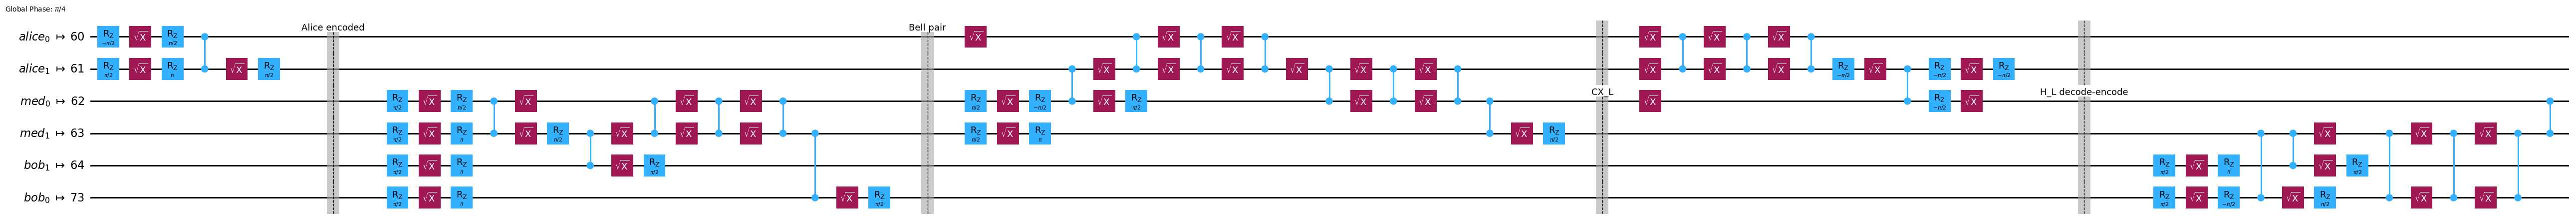

In [46]:
qct.draw('mpl', fold=120,idle_wires=False)

## 4. ノイズモデル構築 (Lindblad synthesis)

選んだ物理 qubit のみに較正ノイズを注入する reduced model。`thermal_relaxation_error` (T1, T2) と `PauliLindbladError` (RB-anchored Pauli rates) を gate ごとに合成。

In [47]:
noise_scale = 1.0  # paper Table V の calibration 一致点
noise_model = create_reduced_noise_model(backend_name, selected, noise_scale=noise_scale)
print(f'Noise model gates: {noise_model.noise_instructions}')
print(f'Noise scale: {noise_scale} (1.0 = device calibration)')

Noise model gates: ['cz', 'id', 'measure', 'sx', 'x']
Noise scale: 1.0 (1.0 = device calibration)


## 5. 密度行列シミュレーションでフィデリティ計算

`compute_dm_fidelity_logical` は内部で:
1. transpile (reduced coupling map で SWAP を物理隣接に閉じ込め)
2. AerSimulator(method='density_matrix') で full DM 計算
3. syndrome 部分 ({00, 11} ⊗ {00, 11}) で post-selection
4. Bob qubit の partial trace を取り、ideal logical Bob 状態と比較

In [48]:
result = compute_dm_fidelity_logical(
    theta, phi,
    noise_model=noise_model,
    backend_name=backend_name,
    selected_qubits=selected,
    gate_pulse_map=DEFAULT_GATE_PULSE_MAP,
    noise_scale=noise_scale,
)
print(f'Logical F (conditional)     : {result["fidelity"]:.4f}')
print(f'Error detection rate        : {result["error_detection_rate"]:.4f}')
print(f'Acceptance (1 - EDR)        : {1 - result["error_detection_rate"]:.4f}')

ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.r

Logical F (conditional)     : 0.9769
Error detection rate        : 0.0737
Acceptance (1 - EDR)        : 0.9263


## 6. 物理 (3-qubit) テレポートとの比較

同じノイズスケールで物理テレポートを実行し、論理 vs 物理の差を見る。

In [49]:
phys_qubits = [66, 67, 74]  # E3DConfig.best_path
phys_noise = create_reduced_noise_model(backend_name, phys_qubits, noise_scale=noise_scale)
phys_result = compute_dm_fidelity_physical(
    theta, phi,
    noise_model=phys_noise,
    backend_name=backend_name,
    selected_qubits=phys_qubits,
    gate_pulse_map=DEFAULT_GATE_PULSE_MAP,
)
print(f'Physical F                  : {phys_result["fidelity"]:.4f}')
print(f'Logical F (conditional)     : {result["fidelity"]:.4f}')
print(f'Delta F (Log - Phys)        : {result["fidelity"] - phys_result["fidelity"]:+.4f}')

ERROR:stevedore.extension:Could not load 'ibm_backend': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_and_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_dynamic_circuits': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.remove_final_measurements' (c:\Users\KS\.pyenv\pyenv-win\versions\3.13.0\Lib\site-packages\qiskit\transpiler\passes\utils\remove_final_measurements.py)
ERROR:stevedore.extension:Could not load 'ibm_fractional': cannot import name 'calc_final_ops' from 'qiskit.transpiler.passes.utils.r

Physical F                  : 0.9849
Logical F (conditional)     : 0.9769
Delta F (Log - Phys)        : -0.0080


## 7. 論文 Table V との照合

論文 §IV.D, Table V の noise=1.0, |+⟩ 行：

| | Phys F | Log F | Accept |
|---|---|---|---|
| 論文の値 | 0.9849 | 0.9769 | 0.9263 |
| 本実行 | (上記) | (上記) | (上記) |

数値が一致していれば、実装と論文の主張が contiguous であることを確認できる。|+⟩ では Log F < Phys F (Z error が [[2,1,1]] では検出不能なため)、ΔF ≈ -0.008 が期待される。

In [50]:
paper = {'Phys F': 0.9849, 'Log F': 0.9769, 'Accept': 0.9263}
this_run = {
    'Phys F': phys_result['fidelity'],
    'Log F': result['fidelity'],
    'Accept': 1 - result['error_detection_rate'],
}
print(f'{"":>10} {"Paper":>10} {"This run":>10} {"Diff":>10}')
for k in paper:
    diff = this_run[k] - paper[k]
    print(f'{k:>10} {paper[k]:>10.4f} {this_run[k]:>10.4f} {diff:>+10.4f}')

                Paper   This run       Diff
    Phys F     0.9849     0.9849    -0.0000
     Log F     0.9769     0.9769    -0.0000
    Accept     0.9263     0.9263    +0.0000
